In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from tqdm import tqdm

from scipy.stats import norm
from sklearn import preprocessing
from scipy.stats import norm
import statistics
from scipy.optimize import curve_fit
from matplotlib.pyplot import cm

from IPython.core.display import display, HTML
#makes plots fit the page

home_dir='/nas/longleaf/home/kbhimani/siggen_ccd/Analysis/Diffusion/test/'

/tmp/ipykernel_3944976/27208327.py:15: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
time = np.arange(0,800,0.2)

In [3]:
k_boz=1.3807 * 10**(-16) # k = 1.3807 × 10-16 cm2 g s-2 K-1
q_e=4.8032 * 10**(-10) # e = 4.8032 × 10-10 cm3/2 g1/2 s-1
temp=90
grid = 0.02
#mu=0.00694379
mu= 4.2 *10**4
k_boz*temp/(q_e*grid**2)

0.0646771943704197

In [4]:
D = mu*k_boz*temp/q_e
r=np.arange(-10,10,0.02)
t=0
print('calculate D is', D, 'simulated D is', 0.00833255)

calculate D is 1.086576865423051 simulated D is 0.00833255


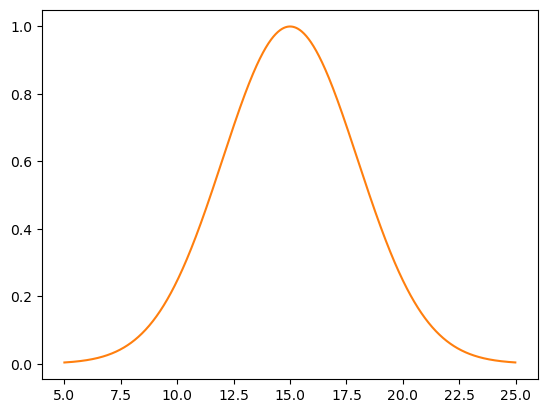

In [5]:
t=700*0.2
D=0.00833247
plt.plot(15 + r, np.exp(-r**2/(4*D*t)/np.sqrt(4*np.pi*D*t)),color='tab:orange')

In [16]:
directory_20m = home_dir
directory_10m = home_dir
i=700
imp_rad=15 #r location of impact
imp_height=5 #z location of impact
r_min=14.5
r_max=15.5

In [17]:
data_e_20m=np.loadtxt(directory_20m+ 'ed{:03d}.dat'.format(i))
data_h_20m=np.loadtxt(directory_20m+ 'hd{:03d}.dat'.format(i))
data_e_10m=np.loadtxt(directory_10m+ 'ed{:03d}.dat'.format(i))
data_h_10m=np.loadtxt(directory_10m+ 'hd{:03d}.dat'.format(i))

rad_e_20m=data_e_20m[:,0]
height_e_20m=data_e_20m[:,1]
dens_r_e_20m=data_e_20m[:,2]
rad_h_20m=data_h_20m[:,0]
height_h_20m=data_h_20m[:,1]
dens_r_h_20m=data_h_20m[:,2]

rad_e_10m=data_e_10m[:,0]
dens_r_e_10m=data_e_10m[:,2]
height_e_10m=data_e_10m[:,1]

rad_h_10m=data_h_10m[:,0]
dens_r_h_10m=data_h_10m[:,2]
height_h_10m=data_h_10m[:,1]


In [18]:
diff_rad_e_20m = rad_e_20m[(dens_r_e_20m>0) & (height_e_20m==imp_height)]
diff_den_r_e_20m = dens_r_e_20m[(dens_r_e_20m>0) & (rad_e_10m==imp_rad)]
diff_h_e_20m = height_e_20m[(dens_r_e_20m>0) & (rad_e_20m==imp_rad)]


diff_rad_h_20m = rad_h_20m[(dens_r_h_20m>0) & (height_h_20m==imp_height)]
diff_den_r_h_20m = dens_r_h_20m[(dens_r_h_20m>0) & (rad_e_10m==imp_rad)]
diff_h_h_20m = height_h_20m[(dens_r_h_20m>0) & (rad_h_20m==imp_rad)]


diff_rad_e_10m = rad_e_10m[(dens_r_e_10m>0) & (height_e_10m==imp_height)]
diff_den_r_e_10m = dens_r_e_10m[(dens_r_e_10m>0) & (rad_e_10m==imp_rad)]
diff_h_e_10m = height_e_10m[(dens_r_e_10m>0) & (rad_e_10m==imp_rad)]

diff_rad_h_10m = rad_h_10m[(dens_r_h_10m>0) & (height_h_10m==imp_height)]
diff_den_r_h_10m = dens_r_h_10m[(dens_r_h_10m>0) & (rad_e_10m==imp_rad)]
diff_h_h_10m = height_h_10m[(dens_r_h_10m>0) & (rad_h_10m==imp_rad)]


norm_den_r_e_10m = diff_den_r_e_10m/np.max(diff_den_r_e_10m)
norm_den_r_e_20m = diff_den_r_e_20m/np.max(diff_den_r_e_20m)

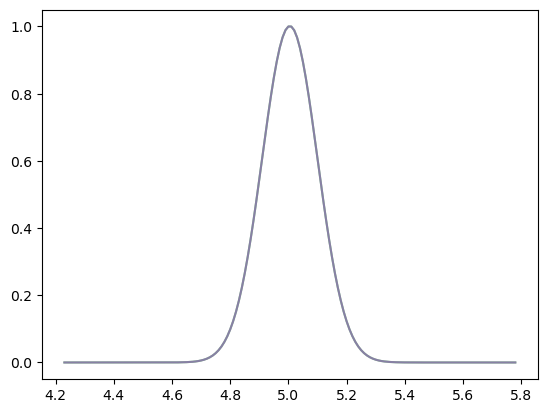

In [19]:
plt.plot(diff_h_e_10m, norm_den_r_e_10m, '-', color='tab:green', alpha=0.7)
plt.plot(diff_h_e_20m, norm_den_r_e_20m, '-', color='tab:purple', alpha=0.7)


In [20]:
def Norm(x, mu, sigma):
    #y = A*np.exp(-1*B*x**2)
    y=(1/(sigma*np.sqrt(2*np.pi)))*np.exp((-(x-mu)**2)/(2*sigma**2))
    return y

def Gauss(x, a_gaus, b_gaus, c_gaus):
    y = a_gaus*np.exp(-(x-b_gaus)**2/(2*c_gaus**2))
    return y

In [21]:
radius = rad_e_20m[(dens_r_e_20m>0) & (height_e_20m==imp_height)]
frequency = dens_r_e_20m[(dens_r_e_20m>0) & (height_e_20m==imp_height)]/np.max(dens_r_e_20m[(dens_r_e_20m>0) & (height_e_20m==imp_height)])

# plt.hist(rad_e_20m, weights=dens_r_e_20m, bins=10000, ec='black',color='tab:blue')
#parameters, covariance = curve_fit(Norm, radius, frequency,  p0=[imp_rad,statistics.stdev(frequency)], check_finite='true')

parameters, covariance = curve_fit(Gauss, radius, frequency,  p0=[np.max(frequency),imp_rad,statistics.stdev(frequency)], check_finite='true')

fit_A = parameters[0]
fit_B = parameters[1]
fit_C = parameters[2]

fit_y = Gauss(radius, fit_A, fit_B, fit_C)


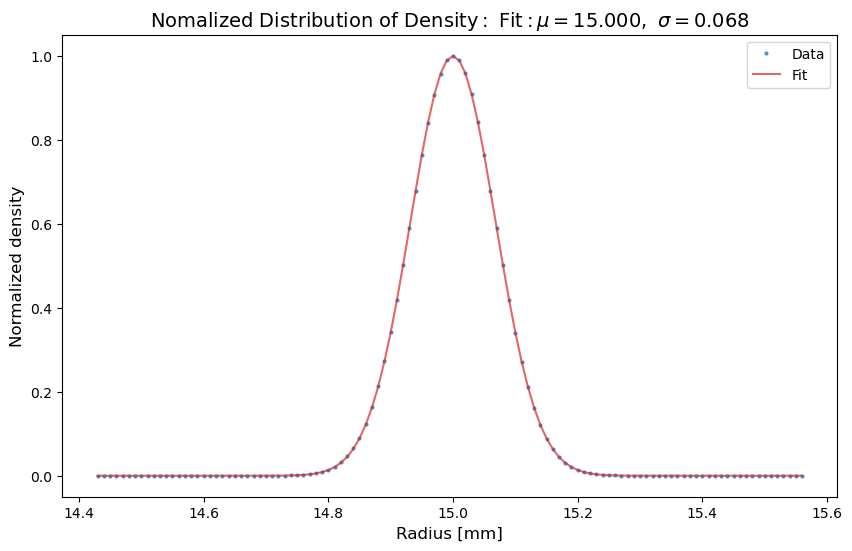

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(radius, frequency, 'o',markersize=2, color='tab:blue', alpha=0.7)
plt.plot(radius, fit_y, '-', color='tab:red', alpha=0.7)


plt.xlabel('Radius [mm]', fontsize=12)
plt.ylabel('Normalized density', fontsize=12)
plt.title(r'$\mathrm{Nomalized\ Distribution\ of\ Density:\ Fit:} \mu=%.3f,\ \sigma=%.3f$' %(fit_B, fit_C), fontsize=14)
plt.legend(['Data','Fit', 'Analytic solution'])

# plt.grid(True)

plt.savefig('figs/diff_fit.pdf')

In [13]:
sim_time=1000
time_step_calc = 0.2
n_iter = sim_time/time_step_calc
step_time_out = 10/time_step_calc #out every step for now
time = np.linspace(start=0, stop= n_iter*time_step_calc - step_time_out*time_step_calc, num= (int) (n_iter/step_time_out))

In [14]:
data_dir = '/pscratch/sd/k/kbhimani/siggen_ccd_data/diffusion_test/'

In [15]:
rad =np.array([])
height = np.array([])
vel_r=np.array([])
vel_z=np.array([])
grid=np.array([])
count=0
# data = pd.DataFrame(columns=['r', 'z', 'vel_r', 'vel_z', 'rho'])
data_vel = pd.DataFrame()
for f in tqdm(os.listdir(data_dir)):
    if('grid' in data_dir + f):
        grid_test = float(f.split("_")[1])
        f_grid = data_dir  + f
        print(f_grid)
        # if(grid_test!=0.03):
        #     continue
        for f_g in (os.listdir(f_grid)):
            if('data_iter_' in f_g):
                # time_array.append(f_g.split('_')[2].split('.')[0])
                df=pd.read_csv(data_dir+f+'/'+f_g, delimiter=',',names=['r', 'z', 'vel_r', 'vel_z', 'rho'])
                # max_df = df[df.rho == df.rho.max()]#.iloc[0]
                # if(len(max_df)>1):
                #     print("Found it!")
                #     max_df = df[df.rho == df.rho.max()].iloc[0]
                #     break
                # if(grid_test==0.03):
                #     print(df[(df['r'] < 15.02) & (df['r'] > 14.98) & (df['z'] < 5.02) & (df['z'] > 4.98)])
                #     break
                try:
                    # rad = np.append(rad, max_df.r.values==15)
                    rad_df = df[(df['r'] < 15.02) & (df['r'] > 14.98) & (df['z'] < 5.02) & (df['z'] > 4.98)]
                    # rad_df = df[(df['r'] < 15.02) & (df['r'] > 14.98) & (df['z'] < 0.12) & (df['z'] > 0.08)]
                    # if(grid_test==0.03):
                    #     print("We shoud append", rad_df)
                    #     break
                    if (len(rad_df)>0):
                        if(len(rad_df)>1):
                            rad_df=rad_df.head(1)
                        # pd.concat([data_vel, rad_df], ignore_index=True)
                        rad = np.append(rad, rad_df.r.values)
                        height = np.append(height, rad_df.z.values)
                        vel_r=np.append(vel_r,rad_df.vel_r.values)
                        vel_z=np.append(vel_z,rad_df.vel_z.values)
                        a=np.empty(len(rad_df.vel_z.values)); a.fill(float(f.split("_")[1]))
                        grid=np.append(grid,a)
                except IndexError:
                    count+=1
                    continue
                # rad.append(max_df.r.values[0])
                # height.append(max_df.z.values[0])
                # vel.append((max_df.vel_r.values[0]**2 + max_df.vel_z.values[0]**2)**0.5)
                # grid.append(f.split("_")[1])
print("Number skipped was", count)

FileNotFoundError: [Errno 2] No such file or directory: '/pscratch/sd/k/kbhimani/siggen_ccd_data/diffusion_test/'

In [ ]:
cut = (rad<15.02) & (rad>14.98) &(height<5.02)&(height>4.98)&(grid==0.020)
print(len(rad[cut]))

In [ ]:
color_array=np.linspace(0,1,11)
cmap = plt.cm.tab20b
color = iter(cm.jet(np.linspace(0, 1, len(np.unique(grid)))))
for g in tqdm(np.unique(grid)):
    cut = (rad<15.02) & (rad>14.98) &(height<5.02)&(height>4.98)&(grid==g)
    r = rad[cut]
    v_r = vel_r[cut]
    v_z = vel_z[cut]
    time_array=np.linspace(0,(len(r)-1)*10,len(r))
    c = next(color)
    plt.plot(time_array, v_r * g,'o', markersize=2, c=c, label='grid='+str(g))
    # plt.plot(g, vel_r[0],'o', markersize=5, c=c, label='grid='+str(g))

plt.xlabel('Grid')
plt.ylabel('Diffusion coefficient')
# plt.ylim(0.06,0.10)
plt.title("Diffusion coefficient in r direction at r=15, z=5")
plt.legend()
# plt.savefig('figs/grids.png')

In [ ]:
color_array=np.linspace(0,1,11)
cmap = plt.cm.tab20b
color = iter(cm.jet(np.linspace(0, 1, len(np.unique(grid)))))
for g in tqdm(np.unique(grid)):
    cut = (rad<15.02) & (rad>14.98) &(height<5.02)&(height>4.98)&(grid==g)
    r = rad[cut]
    v_r = vel_r[cut]
    v_z = vel_z[cut]
    time_array=np.linspace(0,(len(r)-1)*10,len(r))
    c = next(color)
    # plt.plot(time_array, (v_r**2+v_z**2)**0.5 * g,'o', markersize=2, c=c, label='grid='+str(g))
    plt.plot(g, vel_r[0],'o', markersize=5, c=c, label='grid='+str(g))

plt.xlabel('Grid')
plt.ylabel('Diffusion coefficient')
# plt.ylim(0.06,0.10)
plt.title("Diffusion coefficient in r direction at r=15, z=5")
plt.legend()
# plt.savefig('figs/grids.png')